# Bayesian Renewal Forecasting: 4-Week Forecast Examples

This notebook demonstrates how to use the `spatial_bayes_renewal` package to forecast infectious disease dynamics for the next 4 weeks (28 days). We'll show examples of both:
- **ClassicalForecaster**: Single-region model
- **SpatialForecaster**: Multi-region model with spatial effects

We'll generate synthetic data, fit Bayesian renewal models, and visualize 4-week forecasts for hospital admissions and wastewater concentrations.

## 1. Import Required Libraries

In [ ]:
import sys
import os

# Add parent directory to path so we can import spatial_bayes_renewal
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
from datetime import datetime, timedelta
from scipy.stats import lognorm, poisson
import networkx as nx
import warnings
import jax.numpy as jnp
warnings.filterwarnings('ignore')

# Import forecasting models and reusable visualization helpers
from spatial_bayes_renewal import (
    ClassicalForecaster,
    SpatialForecaster,
    distribution,
    visualization,
    accuracy
)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Create Distribution Parameters

Define the key epidemiological distributions needed for the renewal model:

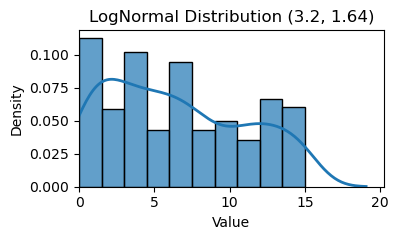

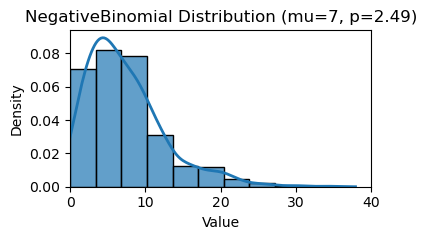

In [ ]:
# Create a helper object for generating epidemiologic distributions
# Point to parent directory Results folder
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
results_dir = os.path.join(parent_dir, 'Results')

process = distribution.Distributions(1000, 1, True, results_dir)

# -----------------------------
# 1. Generation interval distribution
# -----------------------------
# Simulate a lognormal generation-interval distribution,
# then convert it to a normalized discrete probability mass function.
sample = process.lognormal(loc=3.2, scale=1.64, T=15)
generation_interval = process.compute_portion(sample)

# Save the generation interval to a CSV file for later use or inspection
df_generation_interval = pd.DataFrame()
df_generation_interval['time'] = np.arange(len(generation_interval)) + 1
df_generation_interval['pmf'] = generation_interval
df_generation_interval.to_csv(os.path.join(results_dir, 'df_generation_interval.csv'))

# -----------------------------
# 2. Infection-to-admission delay distribution
# -----------------------------
# Recreate the helper object and generate a negative-binomial delay distribution
# for the time between infection and hospital admission.
process = distribution.Distributions(1000, 1, True, results_dir)
sample = process.negative_binomial(mu=7, alpha=2.49, T=55)
admission_interval = process.compute_portion(sample)

# Save the admission delay distribution to CSV
df_admission_interva = pd.DataFrame()
df_admission_interva['time'] = np.arange(len(admission_interval)) + 1
df_admission_interva['pmf'] = admission_interval
df_admission_interva.to_csv(os.path.join(results_dir, 'df_admission_interval.csv'))

## 3. Load Dataset

In [ ]:
from collections import Counter

# Point to parent directory data folder
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
data_dir = os.path.join(parent_dir, 'data')

df_data = pd.read_csv(os.path.join(data_dir, 'df_hosp_COVID_daily_SC_primsa_musc.csv'), index_col=0)
df_data.columns=['date', 'Weekly_Encounters','Weekly_Inpatient_Hospitalizations','Weekly_ED_Visit', 'Weekly_Outpatient','county']

df_data1 = pd.read_csv(os.path.join(data_dir, 'df_combined_hosp_ww_COVID_SC_county.csv'))

df_data = df_data.merge(df_data1[['county','date','pcr_target_avg_conc']], on=['county','date'], how='left')

print(df_data.columns)
df_data = df_data[df_data['date'] >= '2025-07-14']
df_data = df_data[df_data['date'] <= '2025-10-06']

df_data['hosp_obs'] = df_data['Weekly_Encounters'] + 1
df_data['pcr_target_avg_conc'] = df_data['pcr_target_avg_conc'].fillna(10)
df_data['ww_obs'] = np.log(df_data['pcr_target_avg_conc']) / np.log(2)

region_ww = df_data.dropna(subset=['hosp_obs','ww_obs'])['county'].values

n_train = 7 * 8
n_test = 7 * 4

Index(['date', 'Weekly_Encounters', 'Weekly_Inpatient_Hospitalizations',
       'Weekly_ED_Visit', 'Weekly_Outpatient', 'county',
       'pcr_target_avg_conc'],
      dtype='object')


In [ ]:
### load commutting dataset
df_commut = pd.read_csv(os.path.join(data_dir, 'Commuting_flows.csv'))
df_commut = df_commut[(df_commut['State_from FIPS Code']==45) & (df_commut['State_to FIPS Code']==45)]
df_commut['County_from Name'] = list(map(lambda x: x.split(" ")[0], df_commut['County_from Name']))
df_commut['County_to Name'] = list(map(lambda x: x.split(" ")[0], df_commut['County_to Name']))

net_commut = nx.DiGraph()   # or nx.DiGraph() if you want a directed graph

for _, row in df_commut.iterrows():
    if row["County_from Name"] != row["County_to Name"]:
        net_commut.add_edge(row["County_from Name"], row["County_to Name"], weight=row["Workers in Commuting Flow"])

net_commut_norm = nx.DiGraph()
for i in net_commut.nodes():
    weights = []
    for j in net_commut.neighbors(i):
        w = net_commut[i][j]['weight']
        weights.append(w)

    sum_v = np.sum(weights)

    if sum_v == 0:   # avoid division by zero
        continue

    # normalize weights
    for j in net_commut.neighbors(i):
        old_w = net_commut[i][j]['weight']
        net_commut_norm.add_edge(i, j, weight=old_w / sum_v)

region_list = list(net_commut_norm.nodes())

In [6]:
net_commut_norm.edges(data=True)

OutEdgeDataView([('Abbeville', 'Aiken', {'weight': 0.00017972681524083394}), ('Abbeville', 'Anderson', {'weight': 0.36897915168943207}), ('Abbeville', 'Charleston', {'weight': 0.008806613946800863}), ('Abbeville', 'Greenville', {'weight': 0.07782171099928109}), ('Abbeville', 'Greenwood', {'weight': 0.45632638389647734}), ('Abbeville', 'Laurens', {'weight': 0.017253774263120056}), ('Abbeville', 'McCormick', {'weight': 0.021746944644140905}), ('Abbeville', 'Newberry', {'weight': 0.0017972681524083393}), ('Abbeville', 'Pickens', {'weight': 0.03001437814521927}), ('Abbeville', 'Richland', {'weight': 0.0025161754133716753}), ('Abbeville', 'Spartanburg', {'weight': 0.014557872034507549}), ('Aiken', 'Allendale', {'weight': 0.004240657301881791}), ('Aiken', 'Bamberg', {'weight': 0.008083752981712166}), ('Aiken', 'Barnwell', {'weight': 0.09369202226345083}), ('Aiken', 'Calhoun', {'weight': 0.00861383514444739}), ('Aiken', 'Charleston', {'weight': 0.011264245958123508}), ('Aiken', 'Edgefield', {

In [7]:
dict_cty_pop= {"Abbeville": 24400,"Aiken": 168000,"Allendale": 7500,"Anderson": 220368,"Bamberg": 12700,"Barnwell": 20500, "Beaufort": 192000,
    "Berkeley": 227000, "Calhoun": 14300, "Charleston": 436197,"Cherokee": 56700,"Chester": 32483, "Chesterfield": 45600,"Clarendon": 33700,"Colleton": 37700,
    "Darlington": 66000,"Dillon": 30400,"Dorchester": 162800,"Edgefield": 30281,"Fairfield": 22300,"Florence": 138300,"Georgetown": 62700,"Greenville": 581794,
    "Greenwood": 69500,"Hampton": 18100,"Horry": 428408,"Jasper": 37594,"Kershaw": 69900,"Lancaster": 108200,"Laurens": 71880,"Lee": 15900,
    "Lexington": 309500,"Marion": 28500,"Marlboro": 25700,"McCormick": 10180, "Newberry": 38800,"Oconee": 83423,"Orangeburg": 82800,"Pickens": 135000,
    "Richland": 436066,"Saluda": 19100,"Spartanburg": 356698,"Sumter": 104165,"Union": 26605,"Williamsburg": 29900,"York": 303000
}

## 4. Initialize Spatial Forecaster

In [8]:
# Import forecasting models and reusable visualization helpers
from spatial_bayes_renewal import (
    ClassicalForecaster,
    SpatialForecaster,
    distribution,
    visualization,
    accuracy
)

In [ ]:
# Split data into training and test
dates=pd.unique(df_data['date'])
df_train = df_data[df_data['date']< dates[n_train]]

# Initialize Spatial Forecaster
print("Initializing SpatialForecaster...")
forecaster_spatial = SpatialForecaster(
    df_data=df_train,
    spatial_net=net_commut_norm,
    region_list=region_list,
    region_obs_list=region_list,  # Use all regions for hospital observations
    region_ww_obs_list=region_ww,
    cols_concern=['hosp_obs','ww_obs'], #, 'ww_obs'
    n_forecast_points=n_test,  # 4 weeks ahead
    data_path='.',
    Rt_mode='Local',
    num_samples=200,  # Reduced for speed
    num_warmup=100,
    num_chains=2,  # Use at least 2 chains so R-hat can be checked
    progress_bar=True,
    print_summary=True  # Print MCMC diagnostics (R-hat, n_eff, divergences)
)

# Set required parameters
forecaster_spatial.gen_int_array = generation_interval
forecaster_spatial.inf_hosp_array = admission_interval
forecaster_spatial.region_pop=np.array([dict_cty_pop[i] for i in region_list])
# Adjust priors
forecaster_spatial.set_I0=np.array([df_train[df_train['county']==re]['hosp_obs'].values[0] for re in region_list])
forecaster_spatial.set_R0 = 0.5

print("✓ SpatialForecaster initialized")
print(f"  - Regions: {region_list}")
print(f"  - Training data: {n_train} days")
print(f"  - Forecast horizon: {n_test} days ({n_test//7} weeks)")
print(f"  - MCMC: {forecaster_spatial.num_samples} samples, {forecaster_spatial.num_warmup} warmup, {forecaster_spatial.num_chains} chains")

Initializing SpatialForecaster...
✓ SpatialForecaster initialized
  - Regions: ['Abbeville', 'Aiken', 'Anderson', 'Charleston', 'Greenville', 'Greenwood', 'Laurens', 'McCormick', 'Newberry', 'Pickens', 'Richland', 'Spartanburg', 'Allendale', 'Bamberg', 'Barnwell', 'Calhoun', 'Edgefield', 'Fairfield', 'Florence', 'Hampton', 'Horry', 'Lexington', 'Orangeburg', 'Saluda', 'Sumter', 'York', 'Beaufort', 'Berkeley', 'Cherokee', 'Colleton', 'Lancaster', 'Lee', 'Oconee', 'Union', 'Darlington', 'Dillon', 'Dorchester', 'Georgetown', 'Jasper', 'Kershaw', 'Marion', 'Chester', 'Williamsburg', 'Chesterfield', 'Clarendon', 'Marlboro']
  - Training data: 56 days
  - Forecast horizon: 28 days (4 weeks)
  - MCMC: 200 samples, 100 warmup, 2 chains


In [10]:
# Run MCMC inference for the spatial model.
# Because print_summary=True and num_chains=2, the sampler will print
# convergence diagnostics after fitting.
print("\nRunning MCMC inference for spatial model (2-3 minutes)...\n")
samples_spatial, predictions_spatial = forecaster_spatial.run_mcmc()

print("\n✓ Spatial MCMC inference completed")
print("\nConvergence checklist:")
print("  - R-hat should be close to 1.00 (ideally < 1.01)")
print("  - Effective sample size (n_eff) should not be very small")
print("  - Divergences should be zero")
print(f"\nPosterior samples summary:")
for key in samples_spatial.keys():
    val = samples_spatial[key]
    print(f"  - {key}: shape={val.shape}")


Running MCMC inference for spatial model (2-3 minutes)...



sample: 100%|██████████| 300/300 [11:19<00:00,  2.27s/it, 63 steps of size 4.35e-03. acc. prob=0.53]  



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
             I0[0]      1.37      0.30      1.29      0.98      1.89     30.98      1.09
             I0[1]      1.43      0.35      1.43      0.84      1.90     43.94      1.09
             I0[2]      6.64      0.86      6.76      5.11      7.78     26.17      1.07
             I0[3]     13.24      1.13     13.04     11.65     15.56    217.37      1.00
             I0[4]     43.78      2.73     43.20     39.20     48.11     21.11      1.05
             I0[5]      1.41      0.34      1.37      0.96      1.99      9.54      1.18
             I0[6]      6.29      0.70      6.11      4.91      7.27    281.05      1.00
             I0[7]      1.56      0.33      1.55      1.03      1.93      7.32      1.27
             I0[8]      1.99      0.35      1.92      1.50      2.59     21.91      1.06
             I0[9]     15.23      1.36     15.49     12.64     17.04    200.49      1.00
            I0[10]  

TypeError: unsupported operand type(s) for +: 'DynamicJaxprTracer' and 'NoneType'

### How to check convergence
After this cell finishes, read the printed sampler summary.

Use these rules of thumb:
- **R-hat** close to **1.00** for all important parameters
- **Effective sample size (`n_eff`)** not too small
- **No divergences** reported by the sampler

If convergence looks poor, increase `num_warmup`, increase `num_samples`, or use more chains.

## 5. Plot Spatial Model: 4-Week Hospital Forecasts (All Regions)

In [ ]:
# Extract predictions per region
H_pred_spatial = predictions_spatial['H_t']  # shape: (samples, n_regions, time)

# Create multi-region forecast plot


colors = ['darkred', 'steelblue', 'mediumseagreen']

for region_idx, region in enumerate(region_list):
    # Get observed data for this region
    print(f"\nProcessing region: {region}")
    df_data_region = df_data[df_data['county'] == region]
    print(len(df_data_region))
    
    # Get predictions for this region
    H_pred_r = H_pred_spatial[:, region_idx, :]
    
    # Compute statistics
    n_prev = forecaster_spatial.n_previous_points
    T = n_train + n_test  
    print(T)

    H_mean_r = np.mean(H_pred_r, axis=0)[-T:]
    H_median_r = np.median(H_pred_r, axis=0)[-T:]
    H_lower_r = np.percentile(H_pred_r, 2.5, axis=0)[-T:]
    H_upper_r = np.percentile(H_pred_r, 97.5, axis=0)[-T:]

    print(T,len(H_mean_r))

    results_df = pd.DataFrame({
        "date": df_data_region["date"].values[:T],
        "hosp_obs": df_data_region['hosp_obs'].values[:T],
        "pred_mean": H_mean_r,
        "pred_median": H_median_r,
        "pred_lower_95": H_lower_r,
        "pred_upper_95": H_upper_r
    })

    results_df["date"] = pd.to_datetime(results_df["date"], errors="coerce")

    weekly_results = (
        results_df
        .set_index("date")
        .resample("W-SUN")
        .agg({
            "hosp_obs": "sum",
            "pred_mean": "sum",
            "pred_median": "sum",
            "pred_lower_95": "sum",
            "pred_upper_95": "sum"
        })
        .reset_index()
    )

    # Last 4 weeks = forecast period
    true_weekly   = weekly_results['hosp_obs'].values[-4:]
    pred_weekly   = weekly_results['pred_median'].values[-4:]

    control_num=5
    for idx, (i, j) in enumerate(zip(true_weekly, pred_weekly)):
        pa, rmse, dtw_dist = accuracy.measure_accuracy([i+control_num], [j+control_num])
        print("────────────────────────────────────────────────────")
        print(f'county: {region}')
        print(f'week {idx} true_weekly: {i+control_num} pred_weekly: {j+control_num}')
        print(f"  Proportional Accuracy (PA) : {pa:.4f}  ")
        print(f"  RMSE                       : {rmse:.4f}")
        print(f"  DTW Distance               : {dtw_dist:.4f}")
    

    weekly_results['date'] = weekly_results['date'] - pd.Timedelta(days=5)


    # Create Results/Spatial directory if it doesn't exist
    spatial_results_dir = os.path.join(results_dir, 'Spatial')
    os.makedirs(spatial_results_dir, exist_ok=True)
    
    visualization.plot_forecast(
        dates=weekly_results['date'].values,
        hosp_obs=weekly_results['hosp_obs'].values,
        h_center=weekly_results['pred_median'].values,
        h_lower=weekly_results['pred_lower_95'].values,
        h_upper=weekly_results['pred_upper_95'].values,#
        n_train=len(weekly_results) - 4,
        n_test=4,
        save_path=os.path.join(spatial_results_dir, f'Weekly_Forecast_of_Bayesian_{region}.png'),
        show=False
    )



Processing region: Abbeville
85
84


84 84
────────────────────────────────────────────────────
county: Abbeville
week 0 true_weekly: 12.5 pred_weekly: 16.85988426208496
  Proportional Accuracy (PA) : 0.7414  
  RMSE                       : 4.3599
  DTW Distance               : 4.3599
────────────────────────────────────────────────────
county: Abbeville
week 1 true_weekly: 12.214285714285714 pred_weekly: 17.426219940185547
  Proportional Accuracy (PA) : 0.7009  
  RMSE                       : 5.2119
  DTW Distance               : 5.2119
────────────────────────────────────────────────────
county: Abbeville
week 2 true_weekly: 12.0 pred_weekly: 18.00569725036621
  Proportional Accuracy (PA) : 0.6665  
  RMSE                       : 6.0057
  DTW Distance               : 6.0057
────────────────────────────────────────────────────
county: Abbeville
week 3 true_weekly: 12.0 pred_weekly: 18.612781524658203
  Proportional Accuracy (PA) : 0.6447  
  RMSE                       : 6.6128
  DTW Distance               : 6.6128

Proce